In [23]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [24]:
df = pd.read_csv('/content/datos_limpios.csv')

In [25]:
df.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
1433,2111-DWYHN,0,Male,0,0,0,1,1,0,0,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,0,Mailed check,21.10,21.1,0.70
398,0587-DMGBH,1,Female,0,0,0,8,1,0,DSL,...,0,0,0,0,Month-to-month,1,Electronic check,49.85,365.55,1.66
6809,9667-EQRXU,1,Female,1,0,0,30,0,No phone service,DSL,...,1,0,1,0,Month-to-month,1,Electronic check,40.30,1172.95,1.34
5798,8165-CBKXO,0,Male,0,1,1,66,0,No phone service,DSL,...,1,0,1,1,Two year,1,Credit card (automatic),56.75,3708.4,1.89
624,0916-QOFDP,0,Female,1,1,1,14,1,1,Fiber optic,...,0,0,1,1,Month-to-month,1,Electronic check,95.80,1346.3,3.19


In [26]:
#Eliminando columnas irrelevantes
df = df.drop(columns=["customerID"])

In [27]:
df.sample()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
6253,1,Female,0,1,0,54,1,1,Fiber optic,1,...,0,0,1,1,One year,0,Bank transfer (automatic),106.55,5763.3,3.55


In [28]:
#Transformando variables categóricas a formato numérico
df.select_dtypes(include="object").columns

Index(['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod', 'Charges.Total'],
      dtype='object')

In [29]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df.dropna(inplace=True)

Ahora, identificamos las columnas categóricas restantes y aplicamos One-Hot Encoding.

In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df.head())

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Charges.Daily,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,False,True,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,False,True,False,False,False,False,False,False,False,True


In [31]:
#Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases.
cancel_rate = df['Churn'].value_counts(normalize=True)
cancel_rate

,proportion
Churn,
0,0.734215
1,0.265785


Sí existe desproporción entre clases, ya que aproximadamente el 73.4% de los clientes (0.734215) permanecen activos, mientras que el 26.6% (0.265785) corresponden a clientes que cancelaron el servicio. Esto indica que la clase de clientes activos es considerablemente mayor que la de clientes que cancelaron, lo que genera un desbalance de clases.

In [32]:
#Ahora se debe realizar un balanceo, y por recomendación usaré la herramienta SMOTE
X = df.drop('Churn', axis=1)
y = df['Churn']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

y_res.value_counts()

,count
Churn,
0,5163
1,5163


SMOTE (Synthetic Minority Over-sampling Technique) es una técnica de sobremuestreo que genera ejemplos sintéticos de la clase minoritaria en lugar de simplemente duplicar las instancias existentes.

La normalización dependerá de los modelos que se decidan usar más adelante.

In [33]:
#Análisis de correlación
correlacion = df.corr()
correlacion

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Charges.Daily,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Churn,1.000000,0.150541,-0.149982,-0.163128,-0.354049,0.011691,0.191454,0.192858,-0.199484,0.192914,...,-0.227578,0.063254,-0.227578,0.060860,-0.227578,-0.178225,-0.301552,-0.134687,0.301455,-0.090773
SeniorCitizen,0.150541,1.000000,0.016957,-0.210550,0.015683,0.008392,0.156258,0.219874,0.102411,0.219848,...,-0.182519,0.105445,-0.182519,0.119842,-0.182519,-0.046491,-0.116205,-0.024359,0.171322,-0.152987
Partner,-0.149982,0.016957,1.000000,0.452269,0.381912,0.018397,-0.013957,0.097825,0.319072,0.097884,...,-0.000286,0.124483,-0.000286,0.118108,-0.000286,0.083067,0.247334,0.082327,-0.083207,-0.096948
Dependents,-0.163128,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.110131,-0.112343,0.064653,-0.112395,...,0.138383,-0.016499,0.138383,-0.038375,0.138383,0.069222,0.201699,0.061134,-0.149274,0.056448
tenure,-0.354049,0.015683,0.381912,0.163386,1.000000,0.007877,0.004823,0.246862,0.825880,0.246874,...,-0.037529,0.280264,-0.037529,0.285402,-0.037529,0.202338,0.563801,0.232800,-0.210197,-0.232181
PhoneService,0.011691,0.008392,0.018397,-0.001078,0.007877,1.000000,0.016696,0.248033,0.113008,0.247995,...,0.171817,-0.021383,0.171817,-0.033477,0.171817,-0.003142,0.004442,-0.006916,0.002747,-0.004463
PaperlessBilling,0.191454,0.156258,-0.013957,-0.110131,0.004823,0.016696,1.000000,0.351930,0.157830,0.351917,...,-0.320592,0.224241,-0.320592,0.211583,-0.320592,-0.052278,-0.146281,-0.013726,0.208427,-0.203981
Charges.Monthly,0.192858,0.219874,0.097825,-0.112343,0.246862,0.248033,0.351930,1.000000,0.651065,0.999996,...,-0.763191,0.629668,-0.763191,0.627235,-0.763191,0.004810,-0.073256,0.030055,0.271117,-0.376568
Charges.Total,-0.199484,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,0.651080,...,-0.374878,0.515709,-0.374878,0.519867,-0.374878,0.170569,0.358036,0.182663,-0.060436,-0.294708
Charges.Daily,0.192914,0.219848,0.097884,-0.112395,0.246874,0.247995,0.351917,0.999996,0.651080,1.000000,...,-0.763199,0.629668,-0.763199,0.627206,-0.763199,0.004755,-0.073288,0.030052,0.271144,-0.376571


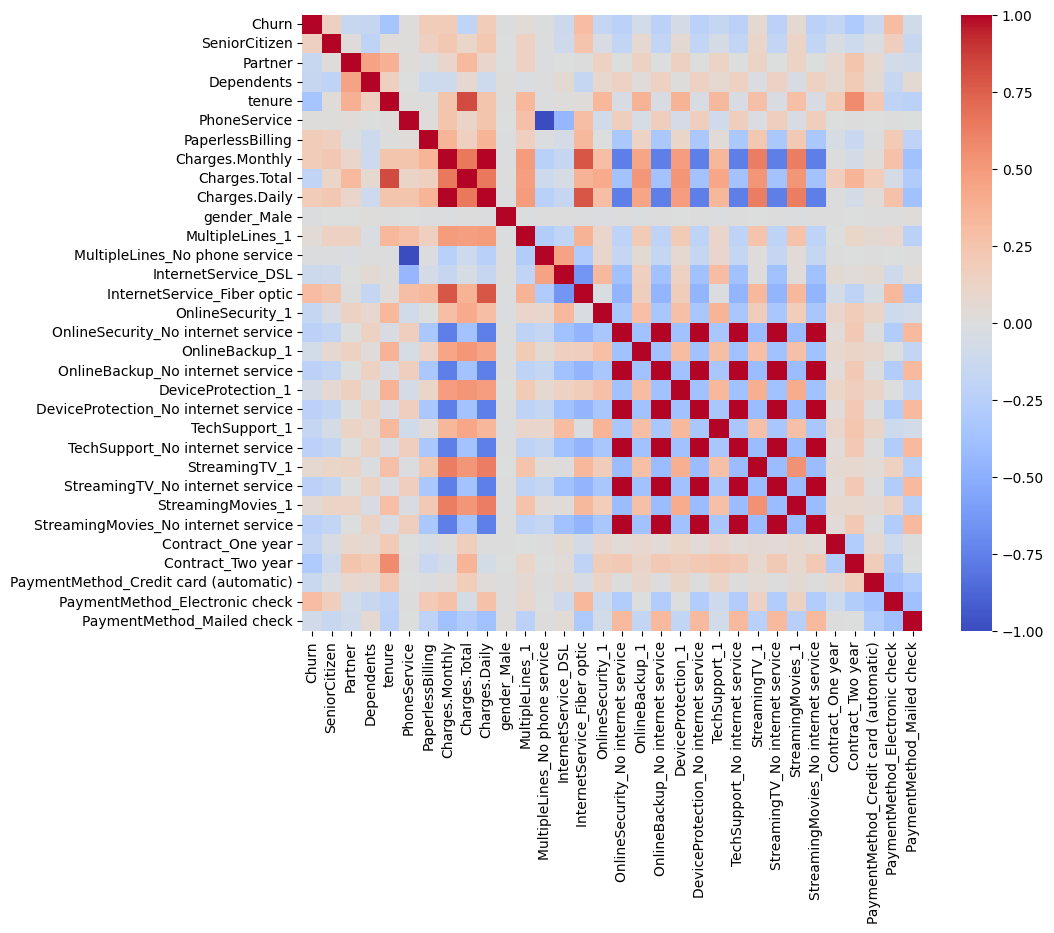

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(correlacion, annot=False, cmap="coolwarm")
plt.show()

In [35]:
df.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Charges.Daily,0.192914
Charges.Monthly,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
StreamingTV_1,0.063254
StreamingMovies_1,0.060860
MultipleLines_1,0.040033


Las variables que muestran mayor correlación con churn son candidatas para el modelo predictivo. Y estas son:
1. InternetService_Fiber optic (0.307)

Es la variable con mayor correlación positiva con Churn. Esto sugiere que los clientes que utilizan internet de fibra óptica tienen mayor probabilidad de cancelar el servicio en comparación con otros tipos de internet.

2. PaymentMethod_Electronic check (0.301)

También presenta una correlación moderada con Churn. Esto indica que los clientes que pagan mediante cheque electrónico tienden a cancelar con mayor frecuencia.

3. Charges.Daily y Charges.Monthly (~0.19)

Ambas variables están relacionadas con los costos del servicio. La correlación positiva indica que a mayor costo del servicio, mayor probabilidad de cancelación.

4. PaperlessBilling (0.19)

Los clientes que utilizan facturación electrónica muestran una ligera mayor tendencia a cancelar el servicio.

Sin embargo, la correlación es débil, por lo que su influencia puede ser limitada.

5. SeniorCitizen (0.15)

Existe una correlación positiva baja entre ser adulto mayor y la cancelación del servicio.

Esto sugiere que este grupo podría tener una ligera mayor probabilidad de abandonar el servicio, aunque la relación no es muy fuerte.

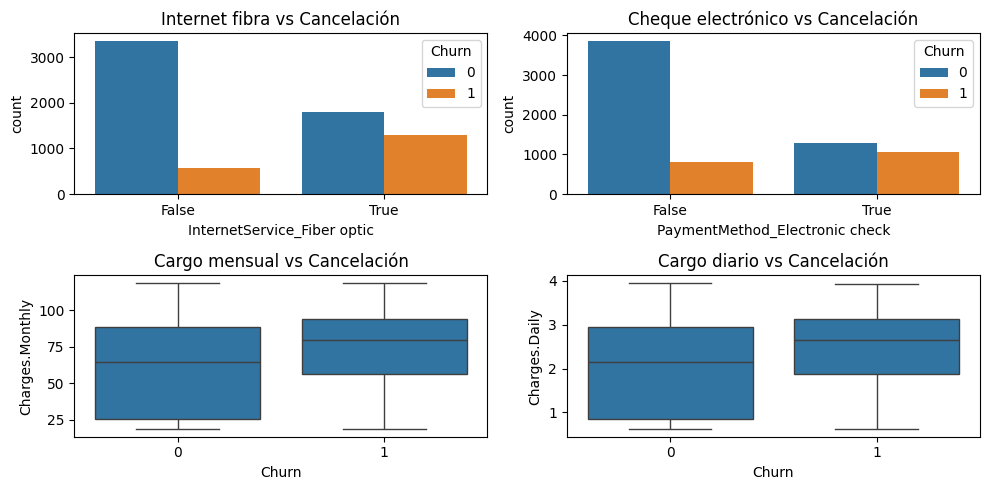

In [36]:
#Relaciones específicas
fig, axes = plt.subplots(2, 2, figsize=(10,5))

# 1 Internet fibra vs churn
sns.countplot(ax=axes[0,0], x='InternetService_Fiber optic', hue='Churn', data=df)
axes[0,0].set_title('Internet fibra vs Cancelación')

# 2 Método de pago vs churn
sns.countplot(ax=axes[0,1], x='PaymentMethod_Electronic check', hue='Churn', data=df)
axes[0,1].set_title('Cheque electrónico vs Cancelación')

# 3 Cargo mensual vs churn
sns.boxplot(ax=axes[1,0], x='Churn', y='Charges.Monthly', data=df)
axes[1,0].set_title('Cargo mensual vs Cancelación')

# 4 Cargo diario vs churn
sns.boxplot(ax=axes[1,1], x='Churn', y='Charges.Daily', data=df)
axes[1,1].set_title('Cargo diario vs Cancelación')

plt.tight_layout()
plt.show()

En las gráficas podemos notar que quienes tienen internet de fibra óptica suelen dejar la empresa en mayor medida que quienes tienen otro tipo de internet. De la misma forma quienes pagan con cheque electrónico dejan la empresa en mayor medida que quienes manejan otro tipo de método de pago. En el caso de los cargos mensuales, se observa que los clientes que cancelan el servicio tienden a presentar valores más altos de cargos mensuales en comparación con aquellos que permanecen activos. De forma similar, los clientes que cancelan el servicio presentan cargos diarios ligeramente más altos, lo que sugiere que los costos del servicio pueden estar asociados con una mayor probabilidad de cancelación.

En este caso decidí no usar los scatterplots porque varias variables eran categóricas, lo que hace que en este caso resulten menos informativas para estudiar la cancelación del servicio.

In [37]:
#Separación de los datos
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [38]:
#Selección de modelos; quiero usar SVM y KNN, entonces debo realizar normalización primero
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
#Usar los datos normalizados en los modelos
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [40]:
print("----- SVM -----")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))

print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_svm))

print("\nMatriz de confusión")
print(confusion_matrix(y_test, y_pred_svm))

----- SVM -----
Accuracy: 0.8028436018957346
Precision: 0.65625
Recall: 0.5287769784172662
F1-score: 0.5856573705179283

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1554
           1       0.66      0.53      0.59       556

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.80      2110


Matriz de confusión
[[1400  154]
 [ 262  294]]


In [41]:
print("----- KNN -----")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_knn))

print("\nMatriz de confusión")
print(confusion_matrix(y_test, y_pred_knn))

----- KNN -----
Accuracy: 0.7573459715639811
Precision: 0.5398550724637681
Recall: 0.5359712230215827
F1-score: 0.5379061371841155

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1554
           1       0.54      0.54      0.54       556

    accuracy                           0.76      2110
   macro avg       0.69      0.69      0.69      2110
weighted avg       0.76      0.76      0.76      2110


Matriz de confusión
[[1300  254]
 [ 258  298]]


El SVM obtuvo mayor exactitud (80%) que KNN (75%), lo que indica que clasifica correctamente una mayor proporción de clientes.

El SVM tiene mayor precisión (0.65) comparado con KNN (0.54).
Esto significa que cuando SVM predice que un cliente cancelará, es más probable que esa predicción sea correcta.

El KNN tiene un recall ligeramente mayor, lo que indica que detecta un poco más de clientes que realmente cancelan. Sin embargo, la diferencia es muy pequeña.

El SVM también obtiene el mejor F1-score (0.59), lo que indica un mejor balance entre precisión y recall.

Al comparar ambos modelos, el Support Vector Machine (SVM) presentó el mejor desempeño general, ya que obtuvo valores superiores en las métricas de exactitud, precisión y F1-score. Aunque el modelo KNN presentó un recall ligeramente mayor, la diferencia fue mínima, por lo que el SVM ofrece un mejor equilibrio entre la capacidad de identificar clientes que cancelan y la precisión de sus predicciones.

**Overfitting**

No parece haber overfitting evidente, ya que las métricas no son exageradamente altas.

**Underfitting**

Tampoco parece haber underfitting fuerte, porque el modelo logra un 80% de exactitud, lo que indica que sí captura patrones relevantes.


**Análisis de variables**

**KNN**: El modelo K-Nearest Neighbors clasifica un nuevo cliente basándose en los k vecinos más cercanos en el espacio de características. El modelo K-Nearest Neighbors clasifica un nuevo cliente basándose en los k vecinos más cercanos en el espacio de características.

**SVM**: El Support Vector Machine busca una frontera de decisión (hiperplano) que separe las dos clases: clientes que cancelan y clientes que permanecen

El modelo intenta maximizar el margen entre ambas clases.

**CONCLUSIONES**

En todo este collab se realizaron distintos procesos, como el análisis exploratorio de datos, donde se pudo observar que existía un claro desbalance de variables, ya que aproximadamente el 73% de los clientes permanecen activos mientras que el 27% cancelan el servicio. A partir de esta información se identificaron variables con mayor relación con la cancelación. Luego, se aplicaron técnicas de preparación de datos, incluyendo la transformación de variables categóricas a formato numérico, la división del conjunto de datos en entrenamiento y prueba, y la normalización de las variables por los modelos que se usaron.

En la etapa de modelado se implementaron los modelos SVM y KNN para predecir la cancelación de clientes. Los resultados mostraron que el modelo SVM obtuvo un mejor desempeño general, alcanzando una exactitud aproximada del 80%, además de valores superiores en precisión y F1-score en comparación con KNN. Aunque el modelo KNN presentó un recall ligeramente mayor, la diferencia fue mínima, por lo que SVM ofreció un mejor equilibrio entre la identificación de clientes que cancelan y la precisión de las predicciones.

En conclusión, los resultados obtenidos sugieren que factores como el tipo de servicio de internet, el método de pago y los cargos del servicio tienen una influencia importante en la cancelación de clientes. Además, el uso de modelos de aprendizaje automático como SVM y KNN permite identificar patrones en los datos y construir herramientas útiles para anticipar el abandono de clientes, lo que puede ayudar a las empresas a diseñar estrategias de retención más efectivas.